In [1]:
# imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from matplotlib.ticker import FuncFormatter

In [3]:
# create list of csv files from dataset path
path = './datasets'
# csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
# print(csv_files)

In [4]:
# load csv
customers_df = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
order_items_df = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
orders_df = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_payments_df = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
products_df = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
sellers_df = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
product_category_name_translation_df = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))
geo_df = pd.read_csv(os.path.join(path, 'olist_geolocation_dataset.csv'))
order_reviews_df = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))

In [5]:

print(orders_df.isna().sum())
orders_df[orders_df['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

### Calculate order specifics and revenue from order_items_df

In [ ]:
# calculate order revenue, products etc. 
items_agg = order_items_df.groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    unique_sellers=('seller_id', 'nunique'),
    unique_products=('product_id', 'nunique')
).reset_index()

items_agg['total_revenue'] = items_agg['total_price'] + items_agg['total_freight']
items_agg.head(5)

,order_id,total_items,total_price,total_freight,unique_sellers,unique_poroducts,total_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,1,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,1,1,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,1,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,1,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,1,1,218.04


### Calculate payments per order

In [7]:
order_payments_df.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [8]:
payments_agg = order_payments_df.groupby('order_id').agg(
    num_payment_methods=('payment_type', 'nunique'),
    max_installments=('payment_installments', 'max'),
    total_payment=('payment_value', 'sum'),
    num_payment_sequence=('payment_sequential', 'max'),
    payment_types=('payment_type', lambda x: ','.join(sorted(x.unique())))
).reset_index()

conditions = [payments_agg['max_installments'] > 1, payments_agg['max_installments'].isna()]
choices = [True, pd.NA]

payments_agg['is_bnpl'] = np.select(conditions, choices, default=False)

payments_agg['is_bnpl'] = payments_agg['is_bnpl'].astype('boolean')
payments_agg.head(5)
# payments_agg['is_bnpl'].dtype

,order_id,num_payment_methods,max_installments,total_payment,num_payment_sequence,payment_types,is_bnpl
0,00010242fe8c5a6d1ba2dd792cb16214,1,2,72.19,1,credit_card,True
1,00018f77f2f0320c557190d7a144bdd3,1,3,259.83,1,credit_card,True
2,000229ec398224ef6ca0657da4fc703e,1,5,216.87,1,credit_card,True
3,00024acbcdf0a6daa1e931b038114c75,1,2,25.78,1,credit_card,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,3,218.04,1,credit_card,True


### Prepare order reviews and customer tables for join

In [9]:
# prepare avg score per order
order_avg_review = order_reviews_df.groupby('order_id')['review_score'].mean().reset_index()

order_avg_review.head(5)

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [10]:
# prepare customers table for merge
customer_info = customers_df[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']]

### Create Master Orders Table

In [11]:
# merge all 4 tables on orders_df
master_orders = (
    orders_df
    .merge(customer_info, on='customer_id', how='left')
    .merge(order_avg_review, on='order_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)

master_orders.shape

(99441, 24)

In [12]:
master_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,total_freight,unique_sellers,unique_poroducts,total_revenue,num_payment_methods,max_installments,total_payment,num_payment_sequence,payment_types,is_bnpl
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,8.72,1.0,1.0,38.71,2.0,1.0,38.71,3.0,"credit_card,voucher",False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,...,22.76,1.0,1.0,141.46,1.0,1.0,141.46,1.0,boleto,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,19.22,1.0,1.0,179.12,1.0,3.0,179.12,1.0,credit_card,True
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,27.20,1.0,1.0,72.20,1.0,1.0,72.20,1.0,credit_card,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,8.72,1.0,1.0,28.62,1.0,1.0,28.62,1.0,credit_card,False


### Data Analysis

#### 1. **Delivery rate** — what % of orders were successfully delivered, on a monthly basis

In [13]:
master_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [14]:
# filter only finished orders for analysis
master_orders_finished = master_orders[master_orders['order_status'].isin({'delivered', 'canceled', 'unavailable'})].copy()

# cast datetime columns
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    master_orders_finished[col] = pd.to_datetime(master_orders_finished[col])

In [15]:
# prepare view with monthly delivery rates
master_orders_finished['approved_yearmonth'] = master_orders_finished['order_approved_at'].dt.strftime('%Y-%m')
monthly_delivery_rate = master_orders_finished.groupby('approved_yearmonth').agg(
    delivery_rate_monthly=('order_status', lambda x: (x == 'delivered').sum()/len(x))
).reset_index().sort_values(by='approved_yearmonth', ascending=False)
monthly_delivery_rate.head(5)

,approved_yearmonth,delivery_rate_monthly
22,2018-08,0.993129
21,2018-07,0.991641
20,2018-06,0.996405
19,2018-05,0.994269
18,2018-04,0.996997


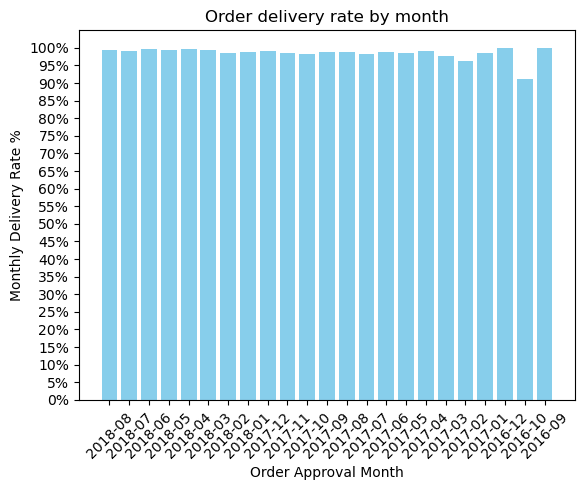

In [16]:
# Visualize the delivery rates
plt.bar(monthly_delivery_rate['approved_yearmonth'], monthly_delivery_rate['delivery_rate_monthly'], color='skyblue')

plt.xlabel('Order Approval Month')
plt.xticks(rotation=45)
plt.ylabel('Monthly Delivery Rate %')
plt.yticks(np.arange(0, 1.05, 0.05))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
plt.title('Order delivery rate by month')

plt.show()

As we can see delivery rates are stable with the only exception being December, 2016. We can specalute that it was the first holiday season for that brazillian shop and most likely they couldn't calculate accordingly for the increased demand. 

#### 2. **Total throughput time** & process step times by months

In [17]:
# filter delivered orders only
master_orders_delivered = master_orders_finished[master_orders_finished['order_status'] == 'delivered'].copy()
master_orders_delivered.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,unique_sellers,unique_poroducts,total_revenue,num_payment_methods,max_installments,total_payment,num_payment_sequence,payment_types,is_bnpl,approved_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,1.0,1.0,38.71,2.0,1.0,38.71,3.0,"credit_card,voucher",False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,1.0,141.46,1.0,1.0,141.46,1.0,boleto,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,1.0,1.0,179.12,1.0,3.0,179.12,1.0,credit_card,True,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,1.0,72.20,1.0,1.0,72.20,1.0,credit_card,False,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,1.0,28.62,1.0,1.0,28.62,1.0,credit_card,False,2018-02


<Axes: xlabel='delivery_yearmonth'>

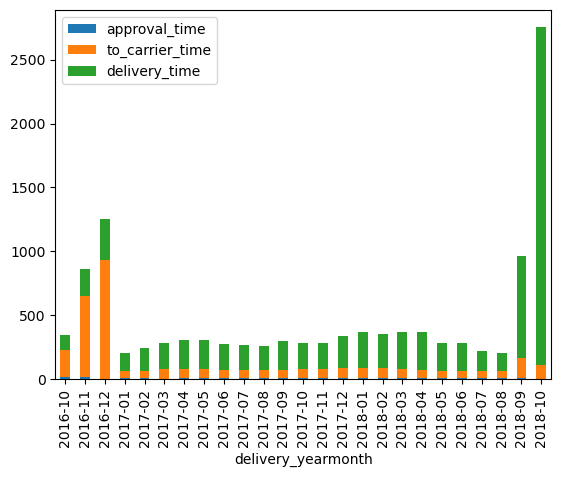

In [18]:
# calculate time spent on each step in the process in hours
master_orders_delivered['approval_time'] = round((master_orders_delivered['order_approved_at'] - master_orders_delivered['order_purchase_timestamp']).dt.total_seconds()/3600, 2)
master_orders_delivered['to_carrier_time'] = round((master_orders_delivered['order_delivered_carrier_date'] - master_orders_delivered['order_approved_at']).dt.total_seconds()/3600 ,2)
master_orders_delivered['delivery_time'] = round((master_orders_delivered['order_delivered_customer_date'] - master_orders_delivered['order_delivered_carrier_date']).dt.total_seconds()/3600 ,2)

master_orders_delivered['delivery_yearmonth'] = master_orders_delivered['order_delivered_customer_date'].dt.strftime('%Y-%m')
monthly_delivery_times = master_orders_delivered.groupby('delivery_yearmonth')[['approval_time', 'to_carrier_time', 'delivery_time' ]].mean().reset_index()

monthly_delivery_times.set_index('delivery_yearmonth').plot(kind='bar', stacked=True)

In [19]:
monthly_delivery_times[monthly_delivery_times['delivery_yearmonth'] == '2018-10']

,delivery_yearmonth,approval_time,to_carrier_time,delivery_time
24,2018-10,0.33,113.403333,2636.87


2018-10 is showing abnormally high delivery time compared to carrier time because, there was only 1 order made in October and that's basically biasing the results

#### 3. Delivery performance - How many orders were delivered on-time, much earlier, late

In [20]:
master_orders_delivered.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,max_installments,total_payment,num_payment_sequence,payment_types,is_bnpl,approved_yearmonth,approval_time,to_carrier_time,delivery_time,delivery_yearmonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,1.0,38.71,3.0,"credit_card,voucher",False,2017-10,0.18,56.80,145.50,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,141.46,1.0,boleto,False,2018-07,30.71,11.11,288.95,2018-08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,3.0,179.12,1.0,credit_card,True,2018-08,0.28,4.91,220.27,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,72.20,1.0,credit_card,False,2017-11,0.30,89.90,226.81,2017-12
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,28.62,1.0,credit_card,False,2018-02,1.03,21.43,46.51,2018-02


In order to assess the delivery performance, we need to compare order_delivered_customer_date to estimated delivery date.
order_delivered_customer_date is timestamp, we need to cast it to date

In [21]:
master_orders_delivered['order_delivered_actual_date'] = master_orders_delivered['order_delivered_customer_date'].dt.normalize()

conditions = [master_orders_delivered['order_delivered_actual_date'] > master_orders_delivered['order_estimated_delivery_date'],
              master_orders_delivered['order_delivered_actual_date'] == master_orders_delivered['order_estimated_delivery_date']
            ]
choices = ['Order Late', 'Order on-time']

master_orders_delivered['delivery_performance'] = np.select(conditions, choices, default='Order Early')

master_orders_delivered.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,num_payment_sequence,payment_types,is_bnpl,approved_yearmonth,approval_time,to_carrier_time,delivery_time,delivery_yearmonth,order_delivered_actual_date,delivery_performance
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,3.0,"credit_card,voucher",False,2017-10,0.18,56.80,145.50,2017-10,2017-10-10,Order Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,boleto,False,2018-07,30.71,11.11,288.95,2018-08,2018-08-07,Order Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,1.0,credit_card,True,2018-08,0.28,4.91,220.27,2018-08,2018-08-17,Order Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,credit_card,False,2017-11,0.30,89.90,226.81,2017-12,2017-12-02,Order Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,credit_card,False,2018-02,1.03,21.43,46.51,2018-02,2018-02-16,Order Early


<Axes: xlabel='delivery_yearmonth'>

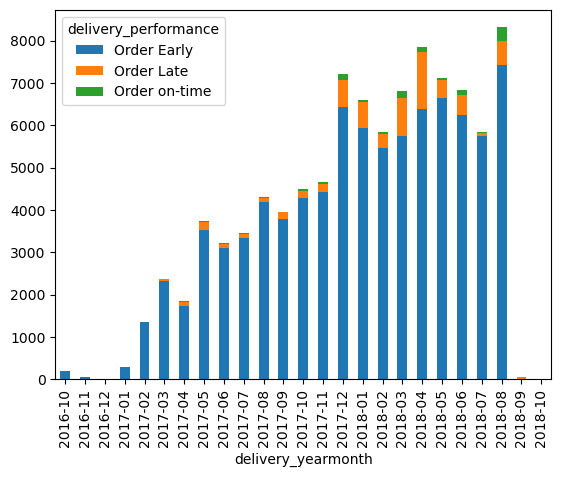

In [22]:
counts = master_orders_delivered.groupby(['delivery_yearmonth', 'delivery_performance'])['delivery_performance'].count()
monthly_perf = counts.unstack(fill_value=0)
monthly_perf.plot(kind='bar', stacked=True)

#### 4. **Sales by geography** — number of orders and total revenue by `customer_city` and `customer_state`

In [23]:
master_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [24]:
# filter only successful orders
master_orders_success = master_orders[~master_orders['order_status'].isin(['canceled', 'unavailable'])].copy()

top10_city_revenue = master_orders_success.groupby('customer_city').agg(
    order_counts=('total_revenue', 'count'),
    order_revenues=('total_revenue', 'sum')
).sort_values(by='order_revenues', ascending=False)[:10]

top10_state_revenue = master_orders_success.groupby('customer_state').agg(
    order_counts=('total_revenue', 'count'),
    order_revenues=('total_revenue', 'sum')
).sort_values(by='order_revenues', ascending=False)[:10]

top10_locations = [top10_city_revenue, top10_state_revenue]

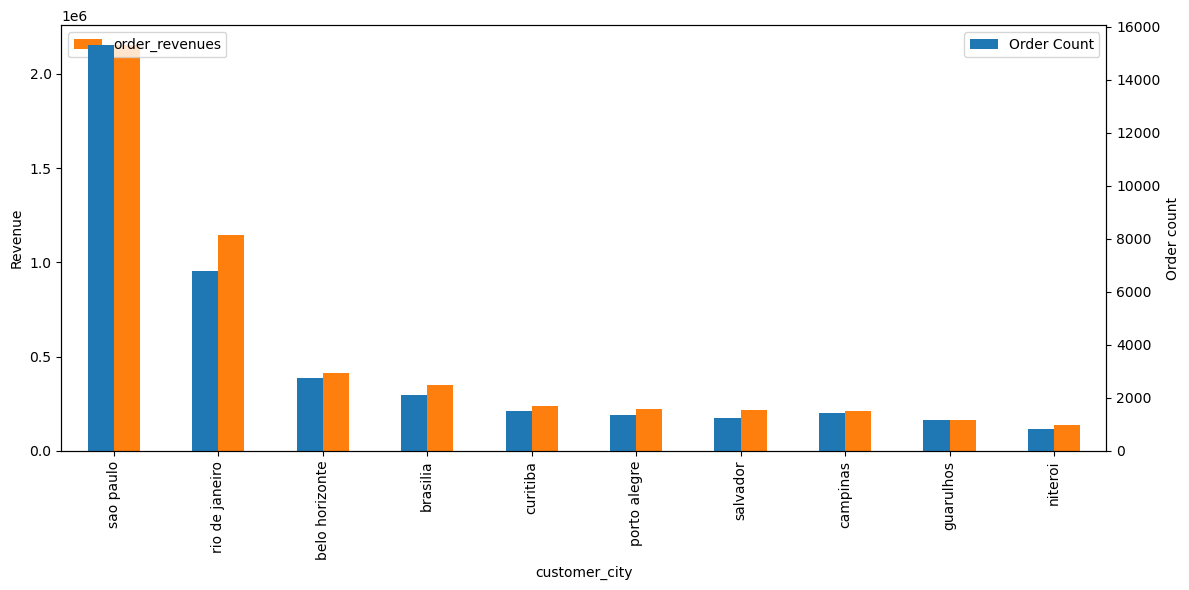

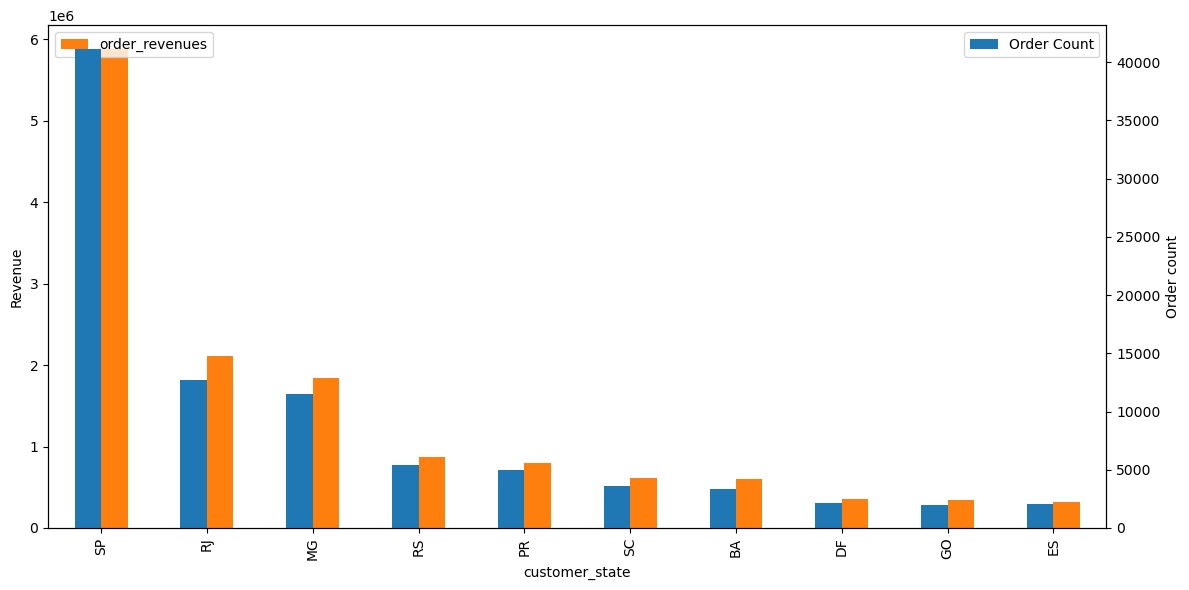

In [25]:
# Visualize the results

for loc in top10_locations:

    ax = loc.plot(
        kind='bar',
        secondary_y='order_counts',
        figsize=(12,6),
        color=['C0','C1']
    )

    # ax.set_xlabel('Customer City')
    ax.set_ylabel('Revenue')
    ax.right_ax.set_ylabel('Order count')
    # ax.set_title('Top 10 Cities by Revenue')
    ax.legend(loc='upper left')
    ax.right_ax.legend(['Order Count'], loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

#### 5. **Order value & size** — average order value (AOV) and average unique number of items per order

In [ ]:
avg_order_value = master_orders_delivered['total_price'].sum()/master_orders_delivered['total_price'].count()
unique_products_per_order = master_orders_delivered['unique_products'].mean()
print(f"Average order value is {avg_order_value:.2f} and unique products per order is {unique_products_per_order:.2f}")
master_orders_delivered.columns

Average order value is 137.04 and unique products per order is 1.04


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state', 'review_score',
       'total_items', 'total_price', 'total_freight', 'unique_sellers',
       'unique_poroducts', 'total_revenue', 'num_payment_methods',
       'max_installments', 'total_payment', 'num_payment_sequence',
       'payment_types', 'is_bnpl', 'approved_yearmonth', 'approval_time',
       'to_carrier_time', 'delivery_time', 'delivery_yearmonth',
       'order_delivered_actual_date', 'delivery_performance'],
      dtype='object')

In [43]:
monthly_avg_order_value = master_orders_delivered.groupby('delivery_yearmonth')['total_price'].mean().reset_index()
monthly_avg_order_value.head(5)

,delivery_yearmonth,total_price
0,2016-10,145.728976
1,2016-11,169.615172
2,2016-12,189.715000
3,2017-01,118.724806
4,2017-02,147.231155


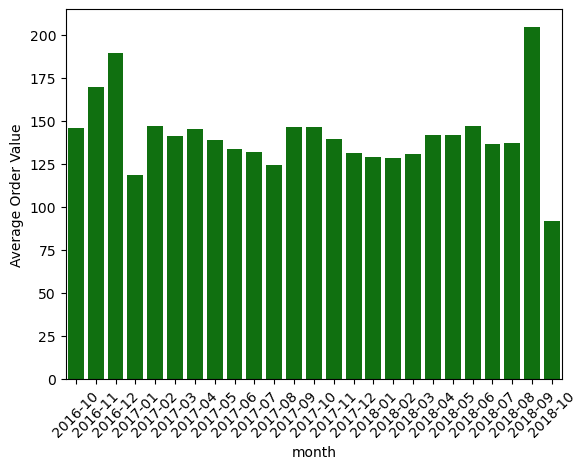

In [47]:
# Visualize average order value monthly basis
sns.barplot(
data=monthly_avg_order_value,
x='delivery_yearmonth',
y='total_price',
color='green'
)

plt.xlabel('month')
plt.xticks(rotation=45)
plt.ylabel('Average Order Value')

plt.show()

#### 6. **Freight vs price** — freight contribution vs product price in total revenue, broken down by customer city

In [51]:
master_orders_delivered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_city', 'customer_state', 'review_score',
       'total_items', 'total_price', 'total_freight', 'unique_sellers',
       'unique_poroducts', 'total_revenue', 'num_payment_methods',
       'max_installments', 'total_payment', 'num_payment_sequence',
       'payment_types', 'is_bnpl', 'approved_yearmonth', 'approval_time',
       'to_carrier_time', 'delivery_time', 'delivery_yearmonth',
       'order_delivered_actual_date', 'delivery_performance',
       'freight_contribution_pct'],
      dtype='object')

In [63]:
# prepare data for visualizing states by top 5 and bottom 5 freight contribution in total cost for customer
master_orders_delivered['freight_contribution_pct'] = master_orders_delivered['total_freight']/master_orders_delivered['total_revenue']
freight_costs = master_orders_delivered.groupby('customer_state').agg(
    total_freight=('total_freight', 'mean'),
    total_order_price=('total_price', 'mean'),
    average_freight_contribution=('freight_contribution_pct', 'mean')
).reset_index()

top5_freight_states = freight_costs.sort_values(by='average_freight_contribution', ascending=False).head(5).copy()
bottom5_freight_states = freight_costs.sort_values(by='average_freight_contribution', ascending=False).tail(5).copy()

mixed_freight_states = pd.concat(
    [top5_freight_states, bottom5_freight_states],
    axis=0,
    ignore_index=True
).sort_values(by='average_freight_contribution', ascending=False)

print(mixed_freight_states.head(10))

  customer_state  total_freight  total_order_price  \
0             RR      48.342683         172.133415   
1             RO      46.433086         187.994897   
2             MA      42.948633         163.192999   
3             AM      37.445724         152.798897   
4             AC      45.554500         199.137125   
5             DF      23.858144         142.547312   
6             SC      24.849309         142.981424   
7             MG      23.463963         136.734352   
8             RJ      23.947404         142.481873   
9             SP      17.334633         125.123655   

   average_freight_contribution  
0                      0.326758  
1                      0.312299  
2                      0.299533  
3                      0.296114  
4                      0.287293  
5                      0.221474  
6                      0.221180  
7                      0.215486  
8                      0.213564  
9                      0.182002  


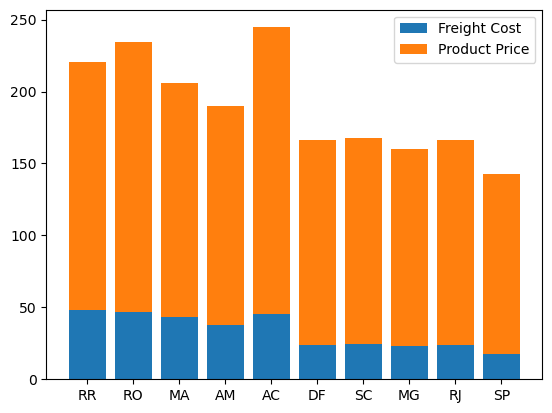

In [66]:
# Visualize the results
plt.bar(
    x=mixed_freight_states['customer_state'],
    height=mixed_freight_states['total_freight'],
    label='Freight Cost'
)
plt.bar(
    mixed_freight_states['customer_state'],
    height=mixed_freight_states['total_order_price'],
    bottom=mixed_freight_states['total_freight'],
    label='Product Price'
    )

plt.legend()
plt.show()

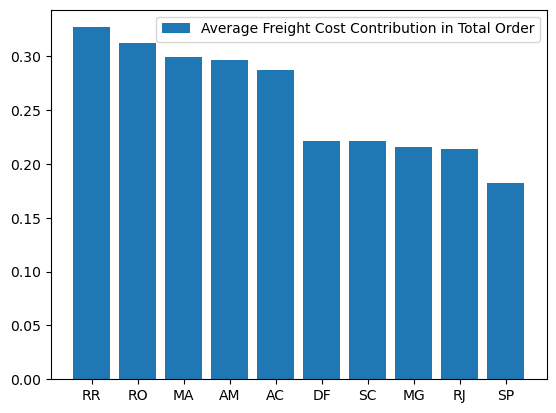

In [67]:
# Top 5 States with freight contribution
plt.bar(
    x=mixed_freight_states['customer_state'],
    height=mixed_freight_states['average_freight_contribution'],
    label='Average Freight Cost Contribution in Total Order'
)

plt.legend()
plt.show()